In [214]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


********************************************

**********************************************

Общая загрузка

In [4]:
df = pd.read_csv('TelcoCustomers.csv')
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [15]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [16]:
df.columns.nunique()

21

In [17]:
df.columns.unique()

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [36]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [47]:
for i in df.columns:
    print(f'{i}: {df[i].unique()}')

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)

In [45]:
count_element = (df['TotalCharges'] == ' ').sum()
print(f'Количество пробелов: {count_element}')

Количество пробелов: 11


In [49]:
for i in df.columns:
    print(f"{i}: {(df[i] == ' ').sum()}")

customerID: 0
gender: 0
SeniorCitizen: 0
Partner: 0
Dependents: 0
tenure: 0
PhoneService: 0
MultipleLines: 0
InternetService: 0
OnlineSecurity: 0
OnlineBackup: 0
DeviceProtection: 0
TechSupport: 0
StreamingTV: 0
StreamingMovies: 0
Contract: 0
PaperlessBilling: 0
PaymentMethod: 0
MonthlyCharges: 0
TotalCharges: 11
Churn: 0


In [50]:
df['TotalCharges'] =  df['TotalCharges'].replace(' ', np.nan)

In [51]:
for i in df.columns:
    print(f"{i}: {(df[i] == ' ').sum()}")

customerID: 0
gender: 0
SeniorCitizen: 0
Partner: 0
Dependents: 0
tenure: 0
PhoneService: 0
MultipleLines: 0
InternetService: 0
OnlineSecurity: 0
OnlineBackup: 0
DeviceProtection: 0
TechSupport: 0
StreamingTV: 0
StreamingMovies: 0
Contract: 0
PaperlessBilling: 0
PaymentMethod: 0
MonthlyCharges: 0
TotalCharges: 0
Churn: 0


In [53]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mode())[0]

In [55]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [56]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [57]:
df['TotalCharges'].dtype

dtype('float64')

******************************************

*******************************************************

Pandas-практика

In [59]:
print(f"Средний tenure: {(df['tenure']).mean()}")
print(f"Средний MonthlyCharges: {(df['MonthlyCharges']).mean()}")
print(f"Средний TotalCharges: {(df['TotalCharges']).mean()}")

Средний tenure: 32.37114865824223
Средний MonthlyCharges: 64.76169246059918
Средний TotalCharges: 29.850000000000005


In [65]:
print('-----------------------------------------------------------------------------')
print(f"Распределение Contract: {(df['Contract']).value_counts()}")
print('-----------------------------------------------------------------------------')
print(f"Распределение InternetService: {(df['InternetService']).value_counts()}")
print('-----------------------------------------------------------------------------')
print(f"Распределение Churn : {(df['Churn']).value_counts()}")
print('-----------------------------------------------------------------------------')

-----------------------------------------------------------------------------
Распределение Contract: Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
-----------------------------------------------------------------------------
Распределение InternetService: InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
-----------------------------------------------------------------------------
Распределение Churn : Churn
No     5174
Yes    1869
Name: count, dtype: int64
-----------------------------------------------------------------------------


In [66]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [76]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,29.85
Yes,17.979133,74.441332,29.85


In [85]:

print(f"Количество клиентов с tenure < 3 месяцев: {df[df['tenure'] < 3].shape[0]}")

Количество клиентов с tenure < 3 месяцев: 862


In [87]:
print(f"Доля клиентов с MonthlyCharges > 100: {len(df[df['MonthlyCharges'] > 100]) / len(df)}")

Доля клиентов с MonthlyCharges > 100: 0.12807042453499928


In [88]:
print(f"средний TotalCharges: {df.groupby('Contract')['TotalCharges'].mean()}")

средний TotalCharges: Contract
Month-to-month    29.85
One year          29.85
Two year          29.85
Name: TotalCharges, dtype: float64


*******************************************************

**************************************************

Визуализация

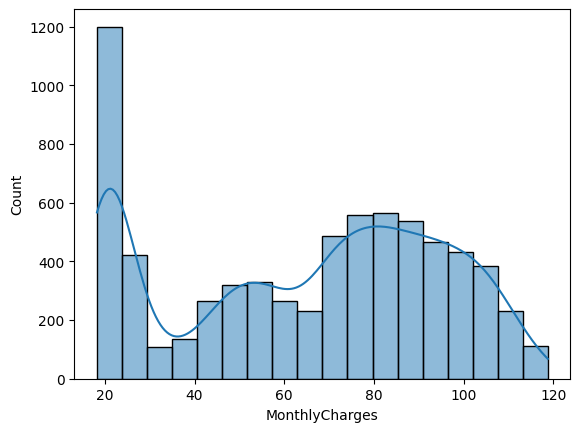

In [91]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

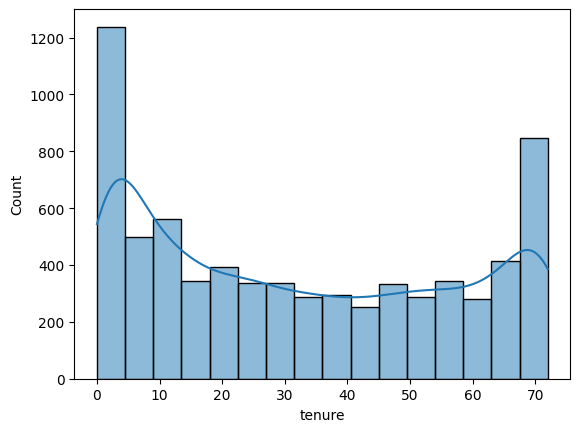

In [92]:
sns.histplot(df['tenure'], kde=True)
plt.show()

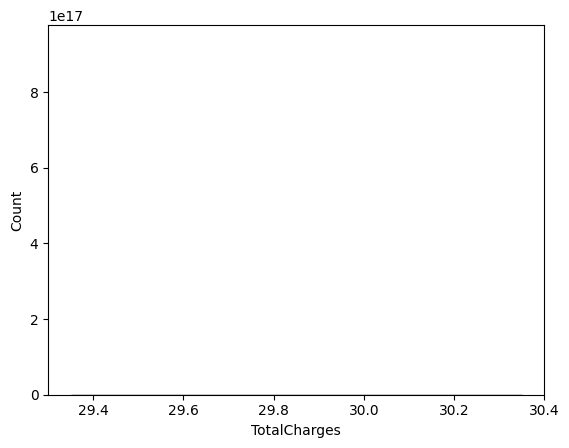

In [93]:
sns.histplot(df['TotalCharges'], kde=True)
plt.show()

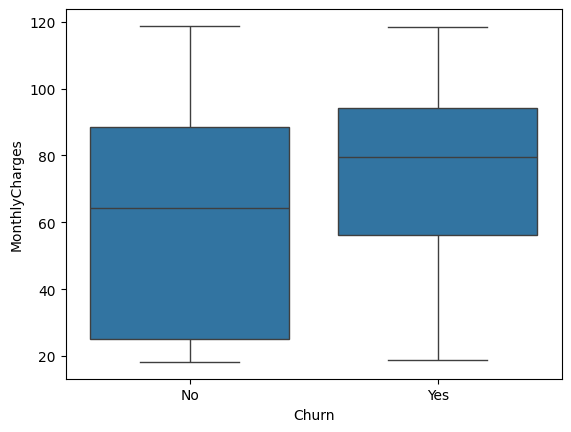

In [95]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.show()

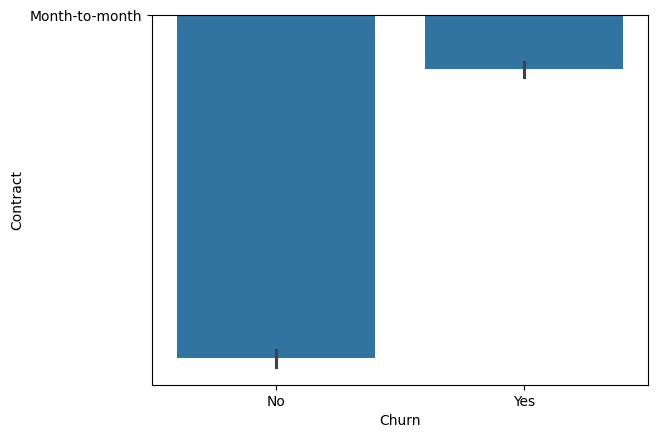

In [97]:
sns.barplot(data=df, x='Churn', y='Contract')
plt.show()

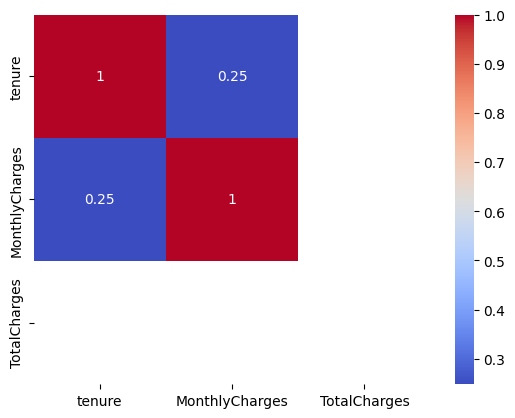

In [103]:
sns.heatmap(data=df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.show()

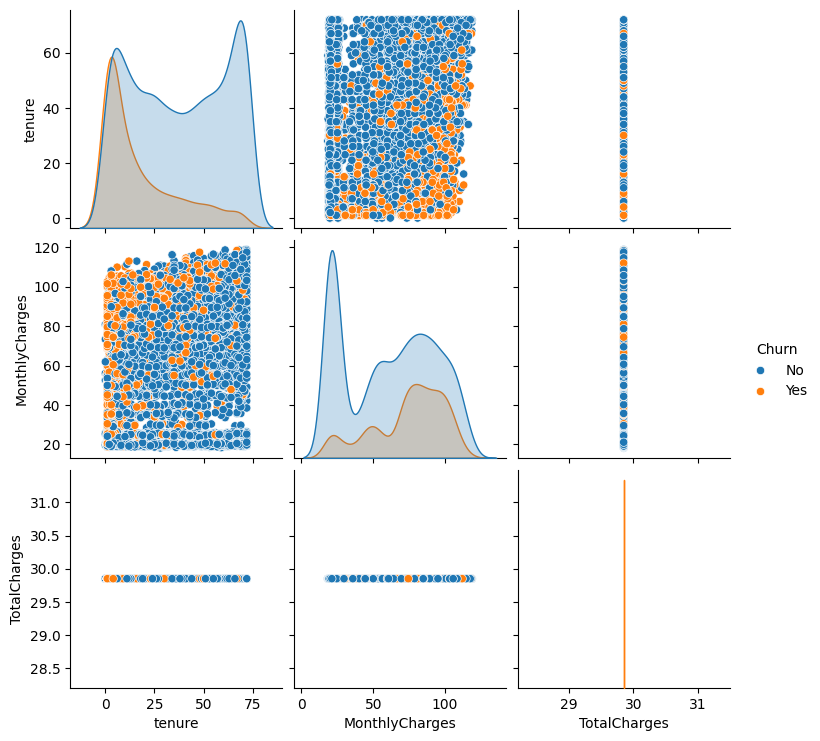

In [114]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
df_subset = df[numeric_cols]
sns.pairplot(data=df_subset, hue='Churn')
plt.show()

****************************************

*********************************************

Предобработка

In [116]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [202]:
df1 = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Churn']]

In [203]:
df1

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,Churn
0,1,29.85,29.85,Month-to-month,DSL,No,No,No
1,34,56.95,29.85,One year,DSL,Yes,No,No
2,2,53.85,29.85,Month-to-month,DSL,Yes,No,Yes
3,45,42.30,29.85,One year,DSL,Yes,Yes,No
4,2,70.70,29.85,Month-to-month,Fiber optic,No,No,Yes
...,...,...,...,...,...,...,...,...
7038,24,84.80,29.85,One year,DSL,Yes,Yes,No
7039,72,103.20,29.85,One year,Fiber optic,No,No,No
7040,11,29.60,29.85,Month-to-month,DSL,Yes,No,No
7041,4,74.40,29.85,Month-to-month,Fiber optic,No,No,Yes


In [210]:
df1['Churn'] = df1['Churn'].map({'Yes': 1, 'No': 0})

In [205]:
df1['Churn'].unique()

array([0, 1])

In [206]:
df1 = pd.get_dummies(df1, columns=['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport'], drop_first=True).astype({'MonthlyCharges': float, 'TotalCharges': float})

In [207]:
for col in df1.columns:
    if col not in ['MonthlyCharges', 'TotalCharges']:
        df1[col] = df1[col].astype(int)

In [209]:
df1

,tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes
0,1,29.85,29.85,0,0,0,0,0,0,0,0,0
1,34,56.95,29.85,0,1,0,0,0,0,1,0,0
2,2,53.85,29.85,1,0,0,0,0,0,1,0,0
3,45,42.30,29.85,0,1,0,0,0,0,1,0,1
4,2,70.70,29.85,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,29.85,0,1,0,0,0,0,1,0,1
7039,72,103.20,29.85,0,1,0,1,0,0,0,0,0
7040,11,29.60,29.85,0,0,0,0,0,0,1,0,0
7041,4,74.40,29.85,1,0,0,1,0,0,0,0,0


In [211]:
scaler = StandardScaler()
features = df1.drop(columns=['Churn'])
scaled_data = scaler.fit_transform(features)

In [212]:
x = scaled_data
y = df['Churn']

In [213]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [215]:
model_lg = LogisticRegression()
model_tree = DecisionTreeClassifier()
model_rf = RandomForestClassifier()

In [216]:
model_lg.fit(x_train, y_train)

LogisticRegression()

In [217]:
model_tree.fit(x_train, y_train)

DecisionTreeClassifier()

In [218]:
model_rf.fit(x_train, y_train)

RandomForestClassifier()

In [219]:
y_predict_lg = model_lg.predict(x_test)
y_predict_tree = model_tree.predict(x_test)
y_predict_rf = model_rf.predict(x_test)

In [220]:
print('accuracy_score:')
print(f'Model Log: {accuracy_score(y_test, y_predict_lg)}')
print(f'Model Tree: {accuracy_score(y_test, y_predict_tree)}')
print(f'Model Rf: {accuracy_score(y_test, y_predict_rf)}')

accuracy_score:
Model Log: 0.8076650106458482
Model Tree: 0.7281760113555713
Model Rf: 0.7707594038325053


In [225]:
print('precision_score:')
print(f'Model Log Precision: {precision_score(y_test, y_predict_lg, pos_label="Yes")}')
print(f'Model Log Recall: {recall_score(y_test, y_predict_lg, pos_label="Yes")}')
print(f'Model Log F1: {f1_score(y_test, y_predict_lg, pos_label="Yes")}')

precision_score:
Model Log Precision: 0.6722972972972973
Model Log Recall: 0.5335120643431636
Model Log F1: 0.5949177877428998


In [226]:
print('recall_score:')
print(f'Model Tree Precision: {precision_score(y_test, y_predict_tree, pos_label="Yes")}')
print(f'Model Tree Recall: {recall_score(y_test, y_predict_tree, pos_label="Yes")}')
print(f'Model Tree F1: {f1_score(y_test, y_predict_tree, pos_label="Yes")}')

recall_score:
Model Tree Precision: 0.4859550561797753
Model Tree Recall: 0.46380697050938335
Model Tree F1: 0.47462277091906724


In [227]:
print('f1_score:')
print(f'Model RF Precision: {precision_score(y_test, y_predict_rf, pos_label="Yes")}')
print(f'Model RF Recall: {recall_score(y_test, y_predict_rf, pos_label="Yes")}')
print(f'Model RF F1: {f1_score(y_test, y_predict_rf, pos_label="Yes")}')

f1_score:
Model RF Precision: 0.5833333333333334
Model RF Recall: 0.4691689008042895
Model RF F1: 0.5200594353640416


In [228]:
print('classification_report:')
print(f'Model Log: {classification_report(y_test, y_predict_lg)}')
print(f'Model Tree: {classification_report(y_test, y_predict_tree)}')
print(f'Model Rf: {classification_report(y_test, y_predict_rf)}')

classification_report:
Model Log:               precision    recall  f1-score   support

          No       0.84      0.91      0.87      1036
         Yes       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Model Tree:               precision    recall  f1-score   support

          No       0.81      0.82      0.82      1036
         Yes       0.49      0.46      0.47       373

    accuracy                           0.73      1409
   macro avg       0.65      0.64      0.65      1409
weighted avg       0.72      0.73      0.73      1409

Model Rf:               precision    recall  f1-score   support

          No       0.82      0.88      0.85      1036
         Yes       0.58      0.47      0.52       373

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg      

In [229]:
joblib.dump(model_rf, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']